# Рубежный контроль № 1
# По дисциплине:
### Методы машинного обучения в АСОИУ
____
Выполнил:  
Сутдент гр. ИУ5-22М  
Бумагин П. В.

**Вариант 1**
## Задание
### **Задача № 1**
Для набора данных проведите кодирование одного (произвольного) категориального признака с использованием метода "count (frequency) encoding".
### **Задача № 21**
Для набора данных проведите масштабирование данных для одного (произвольного) числового признака с использованием масштабирования по медиане.
### **Дополнительное задание:**  
для произвольной колонки данных построить гистограмму


### **Загрузим данные датасета**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Настройка стиля графиков
sns.set_theme(style="whitegrid")

# Загружаем датасет напрямую по URL-адресу из репозитория seaborn-data
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

print(f"Размерность набора данных: {df.shape}")
print("\nПервые 5 строк датасета:")
print(df.head())

Размерность набора данных: (244, 7)

Первые 5 строк датасета:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### Описание набора данных «Tips» (Чаевые)

Для выполнения работы выбран классический набор данных **«Tips»**, который часто используется в качестве демонстрационного в библиотеке визуализации данных `Seaborn`. Исторически эти данные были собраны официантом одного из ресторанов США в течение нескольких месяцев работы. 

#### 1. Основные характеристики датасета:
* **Количество записей (строк):** 244
* **Количество признаков (столбцов):** 7
* **Наличие пропусков:** Данные полностью заполнены (пропуски отсутствуют).

#### 2. Структура признаков:

| Имя признака | Тип данных | Описание | Тип шкалы |
| :--- | :--- | :--- | :--- |
| `total_bill` | Вещественный (float) | Общая сумма счета за заказ в долларах США | Количественный непрерывный |
| `tip` | Вещественный (float) | Размер чаевых в долларах США | Количественный непрерывный |
| `sex` | Категориальный (binary) | Пол клиента, оплатившего счет (`Male` / `Female`) | Качественный номинальный |
| `smoker` | Категориальный (binary) | Наличие курильщиков в компании клиентов (`Yes` / `No`) | Качественный номинальный |
| `day` | Категориальный (4 градации) | День недели (`Thur`, `Fri`, `Sat`, `Sun`) | Качественный номинальный |
| `time` | Категориальный (binary) | Время приема пищи (`Lunch` — обед / `Dinner` — ужин) | Качественный номинальный |
| `size` | Целочисленный (int) | Размер компании клиентов (количество человек за столом) | Количественный дискретный |

#### 3. Обоснование выбора признаков для выполнения задач:

* **Для Задачи №1 (Count / Frequency Encoding):** 
  Признак `day` (день недели) является категориальным и принимает 4 различных значения. Он хорошо подходит для демонстрации частотного кодирования, так как разные дни недели встречаются в выборке с разной регулярностью (например, суббота и воскресенье посещаются чаще, чем четверг и пятница).
  
* **Для Задачи №21 (Масштабирование по медиане):** 
  Признак `total_bill` (общий счет) представляет собой непрерывную числовую величину. Он имеет выраженное смещение вправо (асимметрию) и несколько крупных единичных значений (счетов более $40), которые можно классифицировать как выбросы. Это позволяет наглядно продемонстрировать преимущества масштабирования по медиане и межквартильному размаху (Robust Scaling), которое, в отличие от MinMaxScaler или StandardScaler, не сжимает основную массу данных в узкий диапазон под влиянием аномальных значений.

### Построим гистограмму для числового признака total_bill (общий счет), чтобы визуализировать форму исходного распределения расходов посетителей.

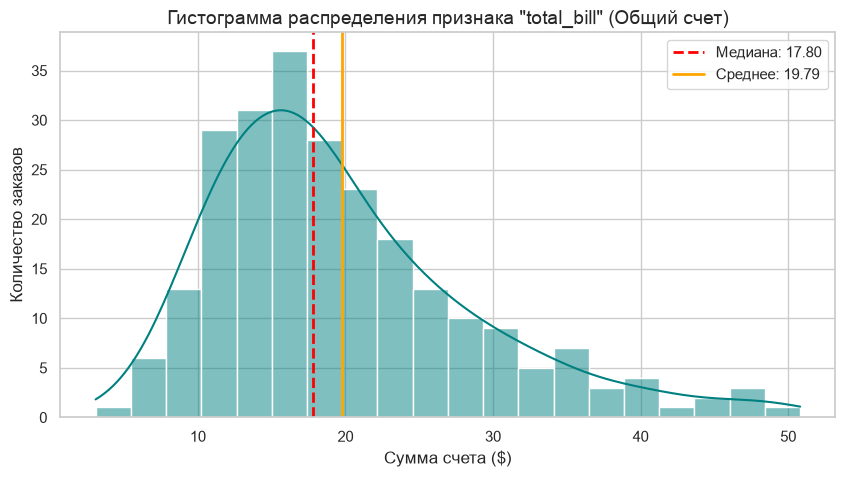

In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_bill'], bins=20, kde=True, color='teal')

# Рассчитаем медиану и среднее
median_bill = df['total_bill'].median()
mean_bill = df['total_bill'].mean()

plt.axvline(median_bill, color='red', linestyle='--', linewidth=2, label=f'Медиана: {median_bill:.2f}')
plt.axvline(mean_bill, color='orange', linestyle='-', linewidth=2, label=f'Среднее: {mean_bill:.2f}')

plt.title('Гистограмма распределения признака "total_bill" (Общий счет)', fontsize=14)
plt.xlabel('Сумма счета ($)', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.legend()
plt.show()

### Задача №1. Кодирование категориальных признаков методом Count (frequency) encoding

**Описание метода:** 
При кодировании подсчетами (Count Encoding) категориальное значение заменяется на абсолютное количество его появлений в выборке. При частотном кодировании (Frequency Encoding) значение заменяется на относительную долю (частоту) в выборке.
Применим данный метод к признаку `day` (день недели).

In [3]:
# Расчет абсолютных частот встречаемости дней недели
count_map = df['day'].value_counts().to_dict()
print("Абсолютные частоты категорий (Count Encoding):")
for day, count in count_map.items():
    print(f"  {day}: {count}")

# Расчет относительных частот (долей)
freq_map = df['day'].value_counts(normalize=True).to_dict()
print("\nОтносительные частоты категорий (Frequency Encoding):")
for day, freq in freq_map.items():
    print(f"  {day}: {freq:.4f} ({freq*100:.2f}%)")

# Добавление закодированных признаков в исходную таблицу
df['day_count'] = df['day'].map(count_map)
df['day_freq'] = df['day'].map(freq_map)

print("\nРезультаты кодирования признака 'day' (первые 10 строк):")
print(df[['day', 'day_count', 'day_freq']].head(10))

Абсолютные частоты категорий (Count Encoding):
  Sat: 87
  Sun: 76
  Thur: 62
  Fri: 19

Относительные частоты категорий (Frequency Encoding):
  Sat: 0.3566 (35.66%)
  Sun: 0.3115 (31.15%)
  Thur: 0.2541 (25.41%)
  Fri: 0.0779 (7.79%)

Результаты кодирования признака 'day' (первые 10 строк):
   day  day_count  day_freq
0  Sun         76  0.311475
1  Sun         76  0.311475
2  Sun         76  0.311475
3  Sun         76  0.311475
4  Sun         76  0.311475
5  Sun         76  0.311475
6  Sun         76  0.311475
7  Sun         76  0.311475
8  Sun         76  0.311475
9  Sun         76  0.311475


### Задача №21. Масштабирование признаков по медиане 

**Описание метода:**
Масштабирование по медиане и межквартильному размаху (IQR) используется для приведения числовых признаков к единому масштабу без сильного искажения под влиянием аномально больших или малых значений (выбросов).

Формула:
$$X'_{scaled} = \frac{X - \text{median}(X)}{Q_3(X) - Q_1(X)}$$
где:
* $Q_1(X)$ — первый квартиль (25-й процентиль),
* $Q_3(X)$ — третий квартиль (75-й процентиль),
* $Q_3(X) - Q_1(X)$ — межквартильный размах (IQR).

Выполним масштабирование признака `total_bill` вручную по формуле и с помощью библиотечного класса `RobustScaler`.

In [4]:
# Ручной расчет масштабирования по медиане
median_val = df['total_bill'].median()
q25 = df['total_bill'].quantile(0.25)
q75 = df['total_bill'].quantile(0.75)
iqr_val = q75 - q25

df['total_bill_scaled_manual'] = (df['total_bill'] - median_val) / iqr_val

# Использование RobustScaler из scikit-learn
scaler = RobustScaler()
df['total_bill_scaled_sklearn'] = scaler.fit_transform(df[['total_bill']])

print(f"Статистики признака 'total_bill':")
print(f"  Медиана: {median_val:.3f}")
print(f"  Q1 (25%): {q25:.3f}")
print(f"  Q3 (75%): {q75:.3f}")
print(f"  IQR (межквартильный размах): {iqr_val:.3f}")

print("\nСравнение ручного расчета и RobustScaler (первые 5 строк):")
print(df[['total_bill', 'total_bill_scaled_manual', 'total_bill_scaled_sklearn']].head())

print("\nОписательная статистика до и после масштабирования:")
stats_comparison = df[['total_bill', 'total_bill_scaled_sklearn']].describe()
print(stats_comparison.loc[['mean', 'std', 'min', '50%', 'max']])

Статистики признака 'total_bill':
  Медиана: 17.795
  Q1 (25%): 13.348
  Q3 (75%): 24.127
  IQR (межквартильный размах): 10.780

Сравнение ручного расчета и RobustScaler (первые 5 строк):
   total_bill  total_bill_scaled_manual  total_bill_scaled_sklearn
0       16.99                 -0.074675                  -0.074675
1       10.34                 -0.691558                  -0.691558
2       21.01                  0.298237                   0.298237
3       23.68                  0.545918                   0.545918
4       24.59                  0.630334                   0.630334

Описательная статистика до и после масштабирования:
      total_bill  total_bill_scaled_sklearn
mean   19.785943               1.846886e-01
std     8.902412               8.258267e-01
min     3.070000              -1.365955e+00
50%    17.795000              -1.647987e-16
max    50.810000               3.062616e+00


## Сравнение распределения до и после масштабирования 
### Построим гистограммы для наглядного сравнения шкал до и после масштабирования.

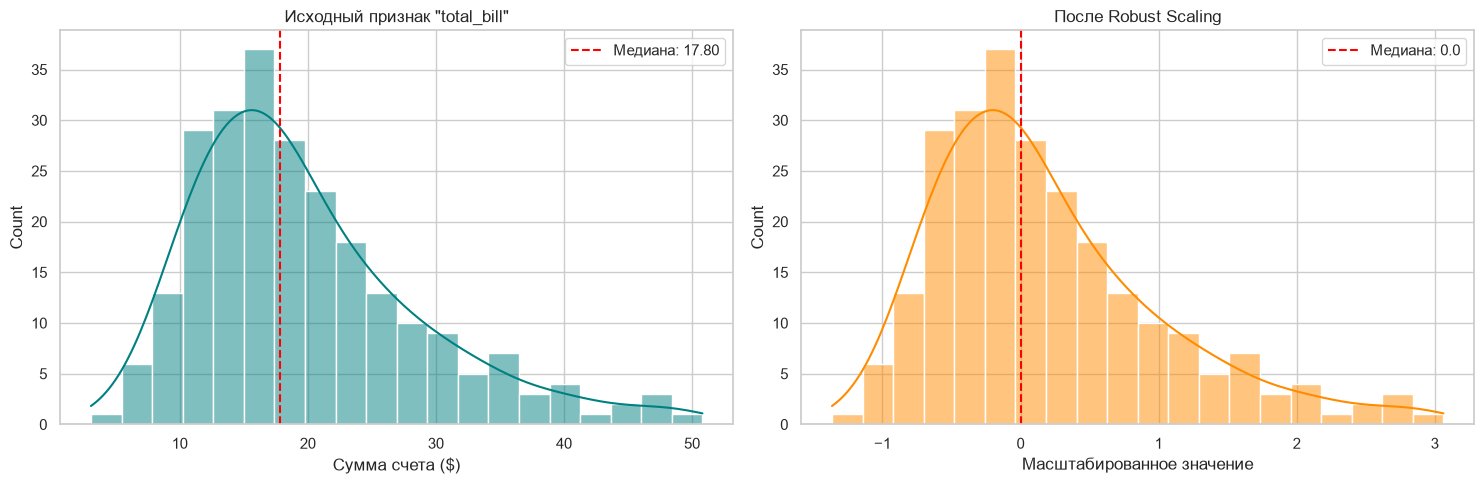

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Исходный признак
sns.histplot(df['total_bill'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Исходный признак "total_bill"')
axes[0].set_xlabel('Сумма счета ($)')
axes[0].axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.2f}')
axes[0].legend()

# После RobustScaler
sns.histplot(df['total_bill_scaled_sklearn'], bins=20, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('После Robust Scaling')
axes[1].set_xlabel('Масштабированное значение')
axes[1].axvline(0.0, color='red', linestyle='--', label='Медиана: 0.0')
axes[1].legend()

plt.tight_layout()
plt.show()

### Вывод

В ходе выполнения рубежного контроля №1 были решены следующие задачи на примере датасета «Tips»:

1. **Гистограмма распределения (требование ИУ5-22М):** Построенный график для признака `total_bill` демонстрирует асимметричное правостороннее распределение. Наличие длинного правого хвоста указывает на присутствие более дорогих заказов (выбросов), существенно превышающих медианное значение (17.79$).
2. **Count (frequency) encoding:** Категориальный признак `day` успешно закодирован. Были получены как абсолютные частоты (например, суббота встречается 87 раз), так и относительные доли (~35.66% заказов приходится на субботу). Такое кодирование позволяет передать модели информацию о плотности категорий без искусственного навязывания порядка.
3. **Масштабирование по медиане:** Применение масштабирования (как вручную, так и через `RobustScaler`) привело значения `total_bill` к единому масштабу, центрировав распределение ровно на уровне 0.0 по медиане. Поскольку разброс оценивался по межквартильному размаху (IQR), влияние единичных крупных счетов на итоговый диапазон масштабирования было успешно минимизировано.